In [18]:
from tensorflow.keras.layers import Input, Lambda, Dense, Flatten, Dropout
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
import itertools


In [19]:
try:
    model = load_model('./my_plant_model.keras')
    print("✓ Loaded existing trained model")
    skip_build = True
except (FileNotFoundError, ValueError):
    print("No existing model found, will build new one")
    skip_build = False

No existing model found, will build new one


In [20]:
archive_path = './Dataset'
print(f"Archive path: {archive_path}")

Archive path: ./Dataset


In [21]:
# List subfolder structure
import os
subfolders = [d for d in os.listdir(archive_path) if os.path.isdir(os.path.join(archive_path, d))]
print(f"Subfolders: {subfolders}")

Subfolders: ['test', 'New Plant Diseases Dataset(Augmented)']


In [22]:
IMAGE_SIZE = [160, 160]
epochs = 60
batch_size = 64

In [23]:
import os
import shutil

# Training files
trainingPath = './Dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train'

# Validation files
validPath = './Dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid'

# Test files - organize flat test folder into class subdirectories
testSourcePath = './Dataset/test/test'
testOrgPath = './Dataset/test/organized'

# Create class folders and organize test images
for filename in os.listdir(testSourcePath):
    if filename.endswith('.JPG'):
        # Extract class name (everything before the number)
        class_name = ''.join([c for c in filename if not c.isdigit()]).replace('.JPG', '')
        
        # Create class folder
        class_path = os.path.join(testOrgPath, class_name)
        os.makedirs(class_path, exist_ok=True)
        
        # Move file
        shutil.move(
            os.path.join(testSourcePath, filename),
            os.path.join(class_path, filename)
        )

print("Test images organized!")
testPath = testOrgPath

Test images organized!


In [24]:
from glob import glob

image_files = glob('./Dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/*/*.jp*g')
folders = glob('./Dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train/*')


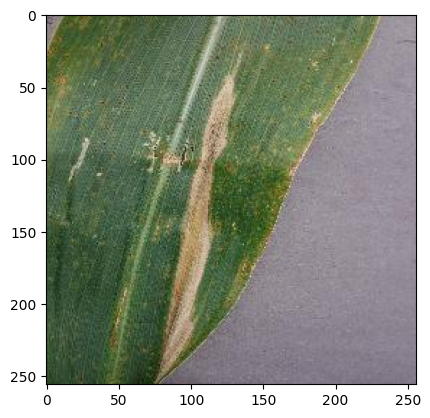

In [25]:
plt.imshow(image.load_img(np.random.choice(image_files)))

In [26]:
if not skip_build:
    print("Building new model...")
    
    resNet = ResNet50(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)
    
    for layer in resNet.layers:
        layer.trainable = False
    
    layers = Flatten()(resNet.output)
    layers = Dense(256, activation='relu')(layers)
    layers = Dropout(0.3)(layers)
    layers = Dense(len(folders), activation='softmax')(layers)
    
    model = Model(inputs = resNet.input, outputs = layers)
    
    model.summary()
    
    from tensorflow.keras.optimizers import Adam
    model.compile(
        loss = 'sparse_categorical_crossentropy',
        optimizer = Adam(learning_rate=0.001),
        metrics = ['accuracy']
    )
else:
    print("Using loaded model, skipping build")

Building new model...


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 166, 166,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 80, 80,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 80, 80,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 80, 80,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 82, 82,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 40, 40,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 40, 40,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 40, 40,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 40, 40,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 40, 40,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 40, 40,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 40, 40,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 40, 40,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 40, 40,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 40, 40,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 40, 40,    │      1,024 │ conv2_block1_3_c

 Total params: 36,704,934 (140.02 MB)

 Trainable params: 13,117,222 (50.04 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [27]:
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    vertical_flip=False,
    preprocessing_function=preprocess_input
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

training_set = train_datagen.flow_from_directory(
    trainingPath,
    target_size=IMAGE_SIZE,
    shuffle=True,
    batch_size=batch_size,
    class_mode='sparse'
)

validation_set = test_datagen.flow_from_directory(
    validPath,
    target_size=IMAGE_SIZE,
    shuffle=False,
    batch_size=batch_size,
    class_mode='sparse'
)

test_set = test_datagen.flow_from_directory(
    testPath,
    target_size=IMAGE_SIZE,
    shuffle=False,
    batch_size=batch_size,
    class_mode='sparse'
)

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.
Found 33 images belonging to 8 classes.


In [28]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

model.fit(
    training_set,
    validation_data=validation_set,
    epochs=epochs,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/60
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 358s 321ms/step - accuracy: 0.7249 - loss: 19.4236 - val_accuracy: 0.9219 - val_loss: 4.3617
Epoch 2/60
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 353s 321ms/step - accuracy: 0.8789 - loss: 7.4806 - val_accuracy: 0.9408 - val_loss: 3.1236
Epoch 3/60
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 351s 319ms/step - accuracy: 0.8996 - loss: 6.3910 - val_accuracy: 0.9506 - val_loss: 2.8701
Epoch 4/60
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 400s 364ms/step - accuracy: 0.9086 - loss: 6.0973 - val_accuracy: 0.9499 - val_loss: 3.2743
Epoch 5/60
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 492s 448ms/step - accuracy: 0.9117 - loss: 6.1600 - val_accuracy: 0.9433 - val_loss: 3.6808


In [29]:
test_results = model.evaluate(test_set)
print(f"Test accuracy: {test_results[1]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.0000e+00 - loss: 722.9568
Test accuracy: 0.0


In [30]:
model.save('./my_plant_model.keras')